In [2]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/kabdoullah/plant-disease-classification.git /content/project 2>/dev/null || (cd /content/project && git pull)

import sys; sys.path.insert(0, '/content/project')
from src import config
from src.utils import set_seed
set_seed(config.SEED)
print("Classes :", config.CLASSES)

Mounted at /content/drive
Classes : ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy']


In [3]:
%cd /content
!rm -rf PlantVillage-Dataset
!git clone --depth 1 --filter=blob:none --sparse \
    https://github.com/spMohanty/PlantVillage-Dataset.git

/content
Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 206, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 206 (delta 37), reused 204 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (206/206), 7.47 MiB | 12.21 MiB/s, done.
Resolving deltas: 100% (37/37), done.
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 9 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 255.05 KiB | 1.06 MiB/s, done.


In [4]:
# Découverte de l'arborescence sans télécharger les images
!git -C /content/PlantVillage-Dataset ls-tree --name-only HEAD
!echo "---"
!git -C /content/PlantVillage-Dataset ls-tree --name-only HEAD raw/

.gitignore
CITATION.cff
README.md
README_HF.md
data_distribution_for_SVM
generate_data_for_SVM.py
generate_lmdb.sh
generate_mapstring.py
generated_for_paper
leaf-map.json
leaf_grouping
logs
plant_village.py
raw
scripts
utils
---
raw/color
raw/grayscale
raw/segmented


In [5]:
import subprocess
from src.data.prepare import _normalize

REPO = "/content/PlantVillage-Dataset"
COLOR_DIR = "raw/color"        # ← ajuster si la cellule 2 montre autre chose

listing = subprocess.run(
    ["git", "ls-tree", "--name-only", "HEAD", f"{COLOR_DIR}/"],
    cwd=REPO, capture_output=True, text=True, check=True).stdout

folders = [l.rstrip("/") for l in listing.splitlines() if l.strip()]
print(f"{len(folders)} classes dans le dépôt\n")

index = {_normalize(p.split("/")[-1]): p for p in folders}
targets, missing = [], []
for canonical in config.CLASSES:
    hit = index.get(_normalize(canonical))
    (targets.append(hit) if hit else missing.append(canonical))
    print(f"  {canonical:32s} -> {hit or '❌ INTROUVABLE'}")

if missing:
    print("\nDossiers disponibles :")
    for p in sorted(folders): print("   ", p.split("/")[-1])
    raise SystemExit("Résolution incomplète — voir la liste ci-dessus.")

38 classes dans le dépôt

  Tomato___Bacterial_spot          -> raw/color/Tomato___Bacterial_spot
  Tomato___Early_blight            -> raw/color/Tomato___Early_blight
  Tomato___Late_blight             -> raw/color/Tomato___Late_blight
  Tomato___Septoria_leaf_spot      -> raw/color/Tomato___Septoria_leaf_spot
  Tomato___healthy                 -> raw/color/Tomato___healthy


In [6]:
# Ne matérialise QUE les 5 dossiers nécessaires
!git -C {REPO} sparse-checkout set {" ".join(targets)}
!du -sh {REPO}/{COLOR_DIR}/*

remote: Enumerating objects: 8384, done.
remote: Counting objects: 100% (8384/8384), done.
remote: Compressing objects: 100% (8384/8384), done.
remote: Total 8384 (delta 0), reused 8384 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8384/8384), 126.57 MiB | 35.32 MiB/s, done.
Updating files: 100% (8407/8407), done.
31M	/content/PlantVillage-Dataset/raw/color/Tomato___Bacterial_spot
17M	/content/PlantVillage-Dataset/raw/color/Tomato___Early_blight
38M	/content/PlantVillage-Dataset/raw/color/Tomato___healthy
29M	/content/PlantVillage-Dataset/raw/color/Tomato___Late_blight
34M	/content/PlantVillage-Dataset/raw/color/Tomato___Septoria_leaf_spot


In [7]:
from src.data.prepare import inventory
import pandas as pd

RAW_ROOT = f"{REPO}/{COLOR_DIR}"
counts = inventory(RAW_ROOT)

df = pd.DataFrame([
    {"Classe": k, "Libellé": config.CLASS_LABELS_FR[k], "Images disponibles": v}
    for k, v in counts.items()
]).sort_values("Images disponibles", ascending=False)

display(df)
print("Total disponible :", df["Images disponibles"].sum())

,Classe,Libellé,Images disponibles
0,Tomato___Bacterial_spot,Tache bactérienne,2127
2,Tomato___Late_blight,Mildiou tardif,1909
3,Tomato___Septoria_leaf_spot,Septoriose,1771
4,Tomato___healthy,Feuille saine,1591
1,Tomato___Early_blight,Alternariose (mildiou précoce),1000


Total disponible : 8398


In [8]:
from src.data.prepare import build_subset

DATA_DIR = "/content/data/tomato5"
stats = build_subset(RAW_ROOT, DATA_DIR)

for k, v in stats.items():
    print(f"{k:32s} {v['available']:5d} dispo -> {v['selected']:4d} retenues")

!ls {DATA_DIR}

Tomato___Bacterial_spot           2127 dispo ->  400 retenues
Tomato___Early_blight             1000 dispo ->  400 retenues
Tomato___Late_blight              1909 dispo ->  400 retenues
Tomato___Septoria_leaf_spot       1771 dispo ->  400 retenues
Tomato___healthy                  1591 dispo ->  400 retenues
_subset_info.json	 Tomato___Early_blight	Tomato___Late_blight
Tomato___Bacterial_spot  Tomato___healthy	Tomato___Septoria_leaf_spot


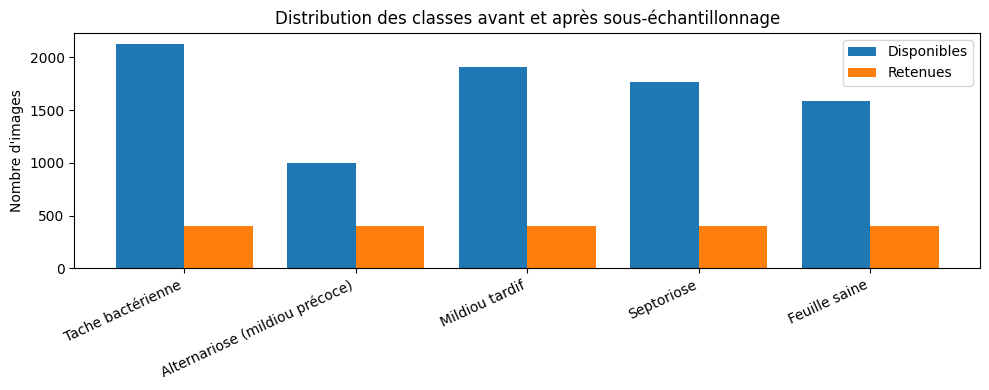

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

FIG_DIR = config.RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Distribution avant / après sous-échantillonnage
fig, ax = plt.subplots(figsize=(10, 4))
labels = [config.CLASS_LABELS_FR[c] for c in config.CLASSES]
x = range(len(config.CLASSES))
ax.bar([i - 0.2 for i in x], [stats[c]["available"] for c in config.CLASSES],
       width=0.4, label="Disponibles")
ax.bar([i + 0.2 for i in x], [stats[c]["selected"] for c in config.CLASSES],
       width=0.4, label="Retenues")
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Nombre d'images"); ax.legend()
ax.set_title("Distribution des classes avant et après sous-échantillonnage")
plt.tight_layout()
plt.savefig(FIG_DIR / "distribution_classes.png", dpi=150)
plt.show()

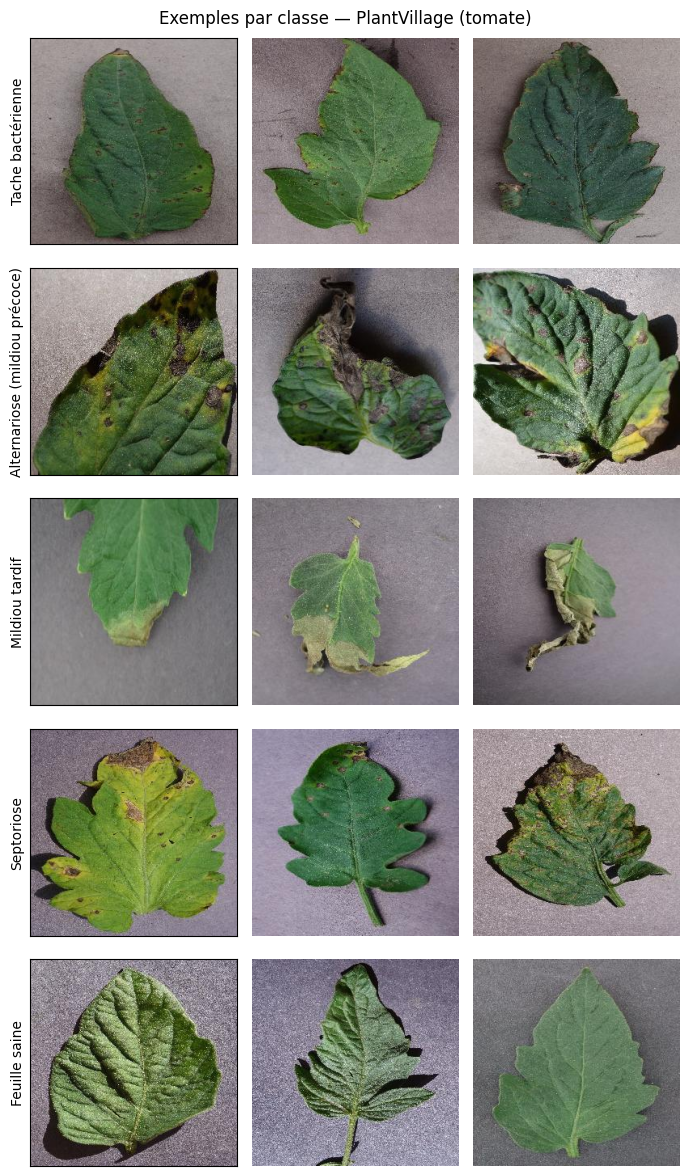

In [10]:
# --- Planche d'exemples : 3 images par classe
fig, axes = plt.subplots(len(config.CLASSES), 3, figsize=(7, 12))
for r, cls in enumerate(config.CLASSES):
    files = sorted(Path(DATA_DIR, cls).glob("*"))[:3]
    for c, f in enumerate(files):
        axes[r, c].imshow(Image.open(f)); axes[r, c].axis("off")
    axes[r, 0].set_ylabel(config.CLASS_LABELS_FR[cls])
    axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
plt.suptitle("Exemples par classe — PlantVillage (tomate)")
plt.tight_layout()
plt.savefig(FIG_DIR / "exemples_classes.png", dpi=150)
plt.show()

In [11]:
# --- Vérification des dimensions
from collections import Counter
sizes = Counter(Image.open(f).size
                for cls in config.CLASSES
                for f in list(Path(DATA_DIR, cls).glob("*"))[:50])
print("Dimensions rencontrées :", dict(sizes))

Dimensions rencontrées : {(256, 256): 250}


In [12]:
from src.data.loaders import make_split_indices, get_dataloaders
from collections import Counter

base, splits = make_split_indices(
    DATA_DIR, save_to=config.RESULTS_DIR / "splits.json")

targets = [lbl for _, lbl in base.samples]
for name, idx in splits.items():
    dist = Counter(config.CLASSES[targets[i]] for i in idx)
    print(f"{name:6s} {len(idx):5d} images  {dict(sorted(dist.items()))}")

loaders = get_dataloaders(DATA_DIR, splits)
images, labels = next(iter(loaders["train"]))
print("\nLot :", images.shape, "| étiquettes :", labels[:8].tolist())
print("Plage après normalisation : "
      f"[{images.min():.2f}, {images.max():.2f}] (valeurs négatives = normal)")

train   1400 images  {'Tomato___Bacterial_spot': 280, 'Tomato___Early_blight': 280, 'Tomato___Late_blight': 280, 'Tomato___Septoria_leaf_spot': 280, 'Tomato___healthy': 280}
val      300 images  {'Tomato___Bacterial_spot': 60, 'Tomato___Early_blight': 60, 'Tomato___Late_blight': 60, 'Tomato___Septoria_leaf_spot': 60, 'Tomato___healthy': 60}
test     300 images  {'Tomato___Bacterial_spot': 60, 'Tomato___Early_blight': 60, 'Tomato___Late_blight': 60, 'Tomato___Septoria_leaf_spot': 60, 'Tomato___healthy': 60}

Lot : torch.Size([32, 3, 224, 224]) | étiquettes : [3, 0, 3, 3, 0, 3, 1, 1]
Plage après normalisation : [-2.12, 2.64] (valeurs négatives = normal)


In [13]:
!cd /content/data && zip -qr /content/tomato5.zip tomato5
!cp /content/tomato5.zip {config.DRIVE_ROOT}/dataset/tomato5.zip
!ls -lh {config.DRIVE_ROOT}/dataset/

total 32M
-rw------- 1 root root 32M Aug 17 13:44 tomato5.zip


In [1]:
import torch, timm, sys
print(sys.version.split()[0], torch.__version__, timm.__version__)

3.12.13 2.11.0+cu128 1.0.28
